## A notebook to analyze groups of crop/trackarrays  

### Read in, combine, and making measurements 

In [1]:
import croparray as ca
from pathlib import Path
%gui qt

In [2]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

# Files & Directories
DATA_DIR_1 = Path("/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210/NoZNF598/PreHT/CombinedStacks/CropArrays")
DATA_DIR_2 = Path("/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210/WithZNF598/BeforeHT/CombinedStacks/CropArrays")
LABELS = ['-ZNF598','+ZNF598']
OUTPUT = Path("/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210") 

nc_files_1 = sorted(DATA_DIR_1.glob("*.nc"))
nc_files_2 = sorted(DATA_DIR_2.glob("*.nc"))

# Measurement parameters
REF_CH = 0  # Optional reference channel for best_z_proj (if use_zc=False, i.e. when Z not tracked)
DISK_R = 5  # Radius of disk in pixels to measure signal
DISK_BG = 7 # Radius of single pixel ring around disk to measure background 
ROLL_N = 3  # Rolling z-average for signal measurement.

In [5]:
nc_files_2

[PosixPath('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210/WithZNF598/BeforeHT/CombinedStacks/CropArrays/Cell01.nc'),
 PosixPath('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210/WithZNF598/BeforeHT/CombinedStacks/CropArrays/Cell02.nc'),
 PosixPath('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210/WithZNF598/BeforeHT/CombinedStacks/CropArrays/Cell03-phase_sep.nc'),
 PosixPath('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210/WithZNF598/BeforeHT/CombinedStacks/CropArrays/Cell04.nc'),
 PosixPath('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210/WithZNF598/BeforeHT/CombinedStacks/CropArrays/Cell05.nc'),
 PosixPath('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210/WithZNF598/BeforeHT/CombinedStacks/CropArrays/Cell06.nc'),
 PosixPath('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210/WithZNF598/BeforeHT/CombinedStacks/CropArrays/Cell07.nc'),
 PosixPath

In [6]:
my_ta = ca.build.open_measure_concat(
    groups=[nc_files_1, nc_files_2],
    dims=["exp", "fov"],
    labels=[["-ZNF598", "+ZNF598"], None],
    measure_kwargs=dict(ref_ch=REF_CH, disk_r=DISK_R, disk_bg=DISK_BG, roll_n=ROLL_N, use_zc=True,drop_int=True # drop full z-stack to save memory, keeping best_z_proj 
    ),
    join="outer",
)

In [7]:
my_ta

TrackArray(tracks=272, t=11)

In [8]:
# Create binary masks from "best_z" so can measure morphological properties. 
my_ta.ops.apply(
    ca.tools.binarize_crop_manual,
    channels=[0],               # Channel used to generate mask
    source="best_z",            # Image layer to threshold (typically z-projected signal)
    out_name="ch{ch}_mask",     # Output mask variable name (→ "ch0_mask")

    # Recommended parameters forwarded directly to binarize_crop_manual(...)
    func_kwargs=dict(
        q=0.45,                 # Threshold at 45% after intensity normalization
        q_range=(0.02, 0.999),  # Normalize intensities using 2%–99.9% quantile range
        q_positive_only=True,   # Ignore negative pixels (important for best_z)
        close_px=1,             # Morphological closing (bridge small gaps)
        smooth_px=0,            # Light smoothing of mask edges
        fill_holes=False,       # Do not fill internal holes
        return_uint8=True,      # Store mask as uint8 (0/1)
        morph_px=0,             # Apply a dilation of final mask (morph_pix > 0; <0 for erosion)
    ),
);

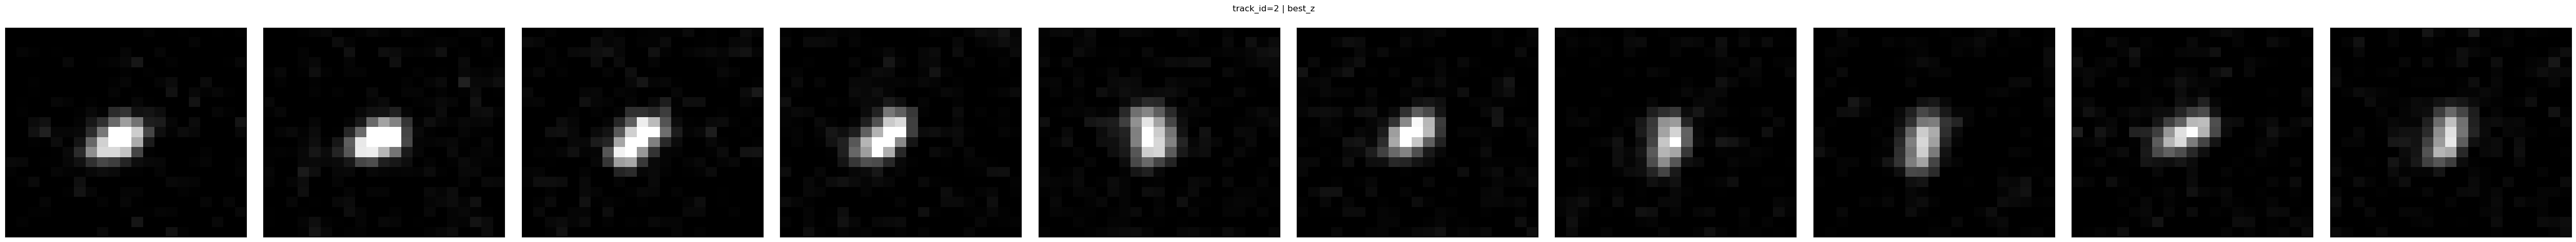

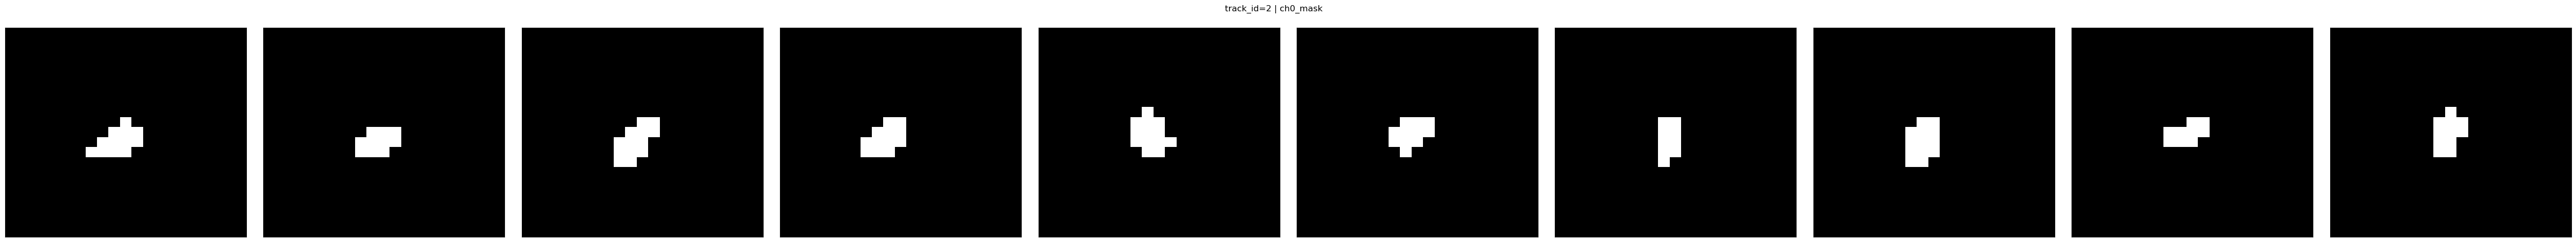

In [17]:
# Check masks, if desired (without napari)
my_ta.sel(exp='+ZNF598', fov='Cell02', ch=0).tplot.plot_trackarray_crops(track_ids=[2],t=(0,10,1),suppress_labels=True);
my_ta.sel(exp='+ZNF598', fov='Cell02', ch=0).tplot.plot_trackarray_crops(track_ids=[2],t=(0,10,1),suppress_labels=True,layer="ch0_mask");

In [18]:
# Check masks with napari
viewer, layers = my_ta.napari.montage_viewer(
    row="track_id",
    col="t",
    show=("best_z", "ch0_mask"),
    #ch=[0, 1, 2],  # RGB
    colormaps={"ch0_mask": "magenta","best_z": "green"},
    image_contrast=[0.5,99.5],
    show_tile_text=True,
)

/home/tstasevi/miniconda3/envs/croparray_env/lib/python3.10/site-packages/napari/layers/utils/style_encoding.py:257: RuntimeWarning: Applying the encoding failed. Using the safe fallback value instead.
  warnings.warn(
/home/tstasevi/miniconda3/envs/croparray_env/lib/python3.10/site-packages/napari/layers/utils/style_encoding.py:257: RuntimeWarning: Applying the encoding failed. Using the safe fallback value instead.
  warnings.warn(


In [19]:
# Make measurements of desired properties 
# See https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops
my_ta.measure.mask_props(source ="ch0_mask", props=['eccentricity','major_axis_length_px','minor_axis_length_px']);

In [20]:
# =======================================
# SAVE YOUR WORK TO A NEW CROP/TRACKARRAY
# =======================================

my_file = ca.io.save_croparray(my_ta, output_dir=OUTPUT)
my_file

/home/tstasevi/projects/croparray/croparray/io.py:451: SerializationWarning: saving variable xc_pix with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
/home/tstasevi/miniconda3/envs/croparray_env/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:253: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/home/tstasevi/projects/croparray/croparray/io.py:451: SerializationWarning: saving variable yc_pix with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
/home/tstasevi/projects/croparray/croparray/io.py:451: SerializationWarning: saving variable zc_pix with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
/home/tstasevi/projects/croparray/croparray/io.py:451: SerializationWarning: saving variable xc_pad with fl

PosixPath('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210/Cell01__28exp_fov.nc')

In [21]:
# check your saved data; note concatenation history is saved
temp = ca.tools.open_trackarray(my_file)
temp

TrackArray(tracks=272, t=11)

### Manual filtering of saved crop/trackarrays

In [1]:
import croparray as ca
from pathlib import Path
%gui qt

In [2]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

INPUT_FILE = Path('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/20260203/Cell_01_zstack__12exp_fov.nc')
INPUT_FILE = Path('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210/Cell01__28exp_fov.nc')

In [3]:
# Need to open this way to get proper doc strings:
from croparray.trackarray.object import TrackArray
my_ta: TrackArray = ca.io.open_trackarray(INPUT_FILE, as_object=True)

In [ ]:
# Quick and user-friendly manual filtering of tracks with napari 
# Create and save filter names (e.g. a 'bad' filter to remove noisy crops/tracks)
# Can also create filters like 'toi' to highlight tracks of interest  
filter_name = "bad"
viewer, layers, ft = my_ta.napari.manual_filter_montage(
    row="track_id",                 
    col="t",  # can be 'track_id' or 't'
    filter_name=filter_name,
    show=("best_z", "ch0_mask"),
    ch=0,
    colormaps={"ch0_mask":"magenta", "best_z":"green", filter_name:"yellow"},
    output_dir= INPUT_FILE.parent,
    show_tile_text=False, # adds layer w/ crop coords; takes memory,
    show_click_info=True, # useful for debugging
)

In [ ]:
# Test your filter:
my_ta.where(my_ta.ds[filter_name] == 0).napari.montage_viewer(row="track_id", col="t",show=("best_z","ch0_mask"),ch=0,show_tile_text=False)

(Viewer(camera=Camera(center=(0.0, np.float64(6982.0), np.float64(104.5)), zoom=np.float64(0.05442176870748299), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(0.0), np.float64(3.0), 0.0, 0.0), viewbox=None, scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=4, ndisplay=2, order=(0, 1, 2, 3), axis_labels=('0', '1', '2', '3'), rollable=(True, True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(1.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(6.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(13964.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(209.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0, 0.0), poi

### Plotting and exploring data

In [2]:
import croparray as ca
from pathlib import Path
%gui qt

In [11]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

INPUT_FILE = Path('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260203/Cell_01_zstack__12exp_fov.nc')
INPUT_FILE = Path('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210/Cell01__28exp_fov.nc')

In [12]:
# Need to open this way to get proper doc strings:
from croparray.trackarray.object import TrackArray
my_ta: TrackArray = ca.io.open_trackarray(INPUT_FILE, as_object=True)

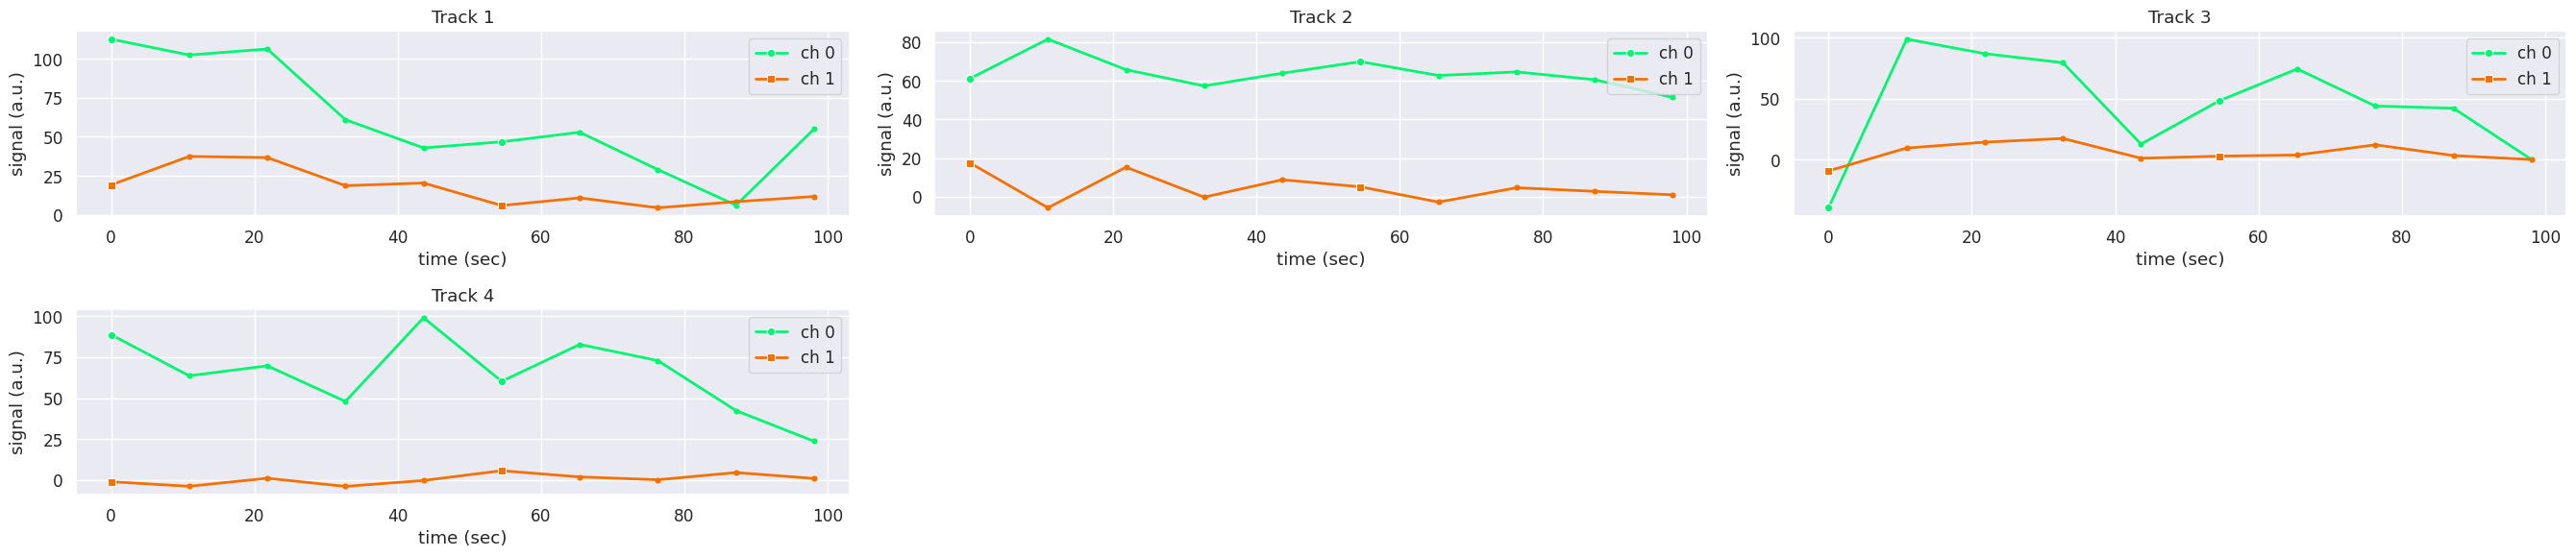

In [13]:
# Plot signals
my_ta.sel(exp='-ZNF598',fov='Cell02').tplot.plot_track_signal_traces(track_ids=[1,2,3,4],figsize=(9,3))

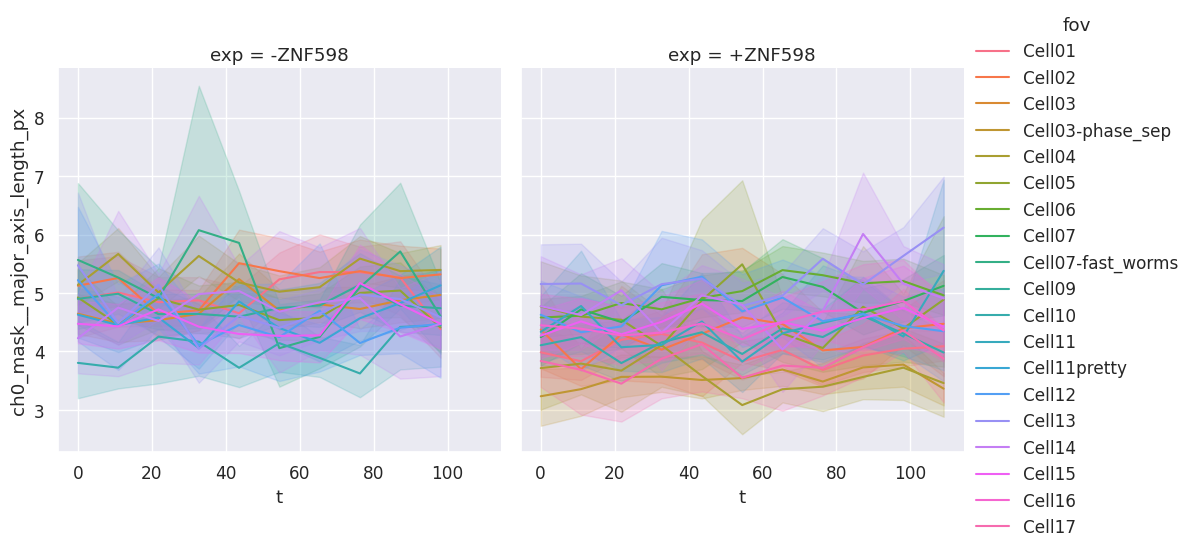

In [14]:
# Make plots using seaborn (relplot, distplot, and catplot supported)

my_ta.where(my_ta.ds["bad"] == 0).plot.relplot(
    x="t", y="ch0_mask__major_axis_length_px",
    kind="line",
    hue="fov",
    col='exp',
    # col_wrap=4,
    #hue="ch",
    # estimator=None,          # prevents seaborn from averaging
    facet_kws={"sharey": True},
)


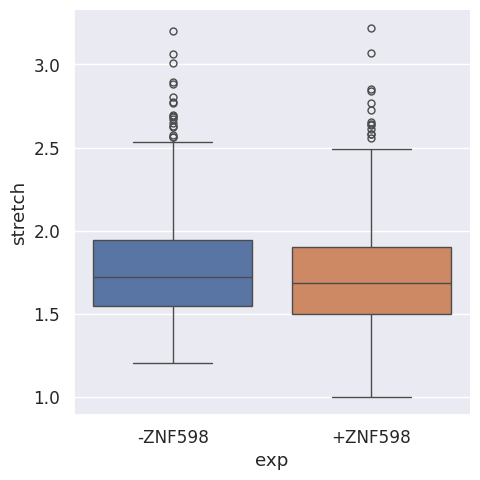

In [15]:
my_ta.ds["stretch"]=my_ta.ds["ch0_mask__major_axis_length_px"]/my_ta.ds["ch0_mask__minor_axis_length_px"]
my_ta.where(my_ta.ds["bad"] == 0).mean(dim='t').plot.catplot(
    x="exp", y="stretch",
    kind="box",
    hue="exp",
)

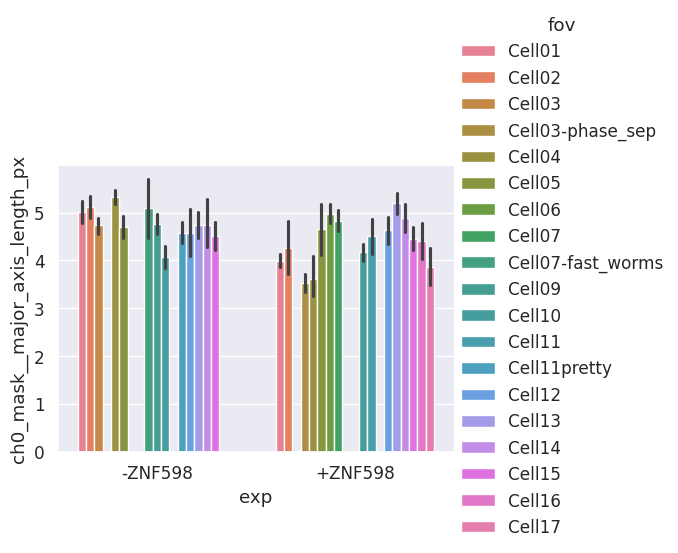

In [16]:
my_ta.where(my_ta.ds["bad"] == 0).mean(dim='t').plot.catplot(
    x="exp", y="ch0_mask__major_axis_length_px",
    kind="bar",
    hue="fov",
)

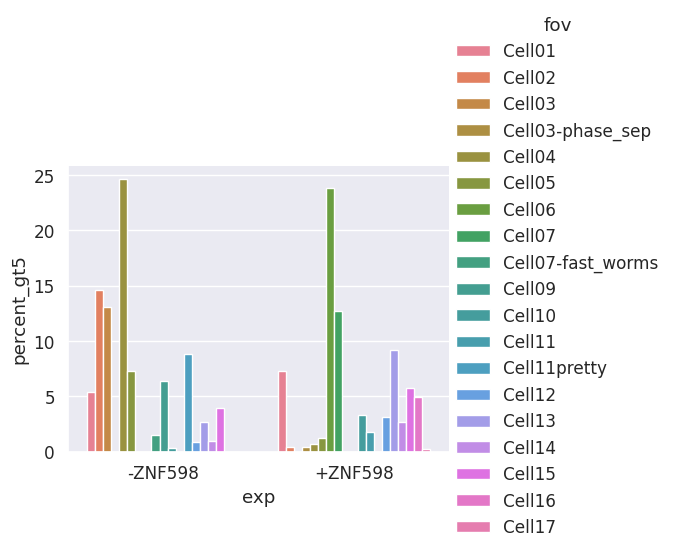

In [17]:
calc = (
    (my_ta.where(my_ta["bad"] == 0)
           ["ch0_mask__major_axis_length_px"] > 5)
    .mean(dim=("track_id","t")) * 100
)
my_ta["percent_gt5"] = calc
my_ta.plot.catplot(
    x="exp",
    y="percent_gt5",
    kind="bar",
    hue="fov",
)

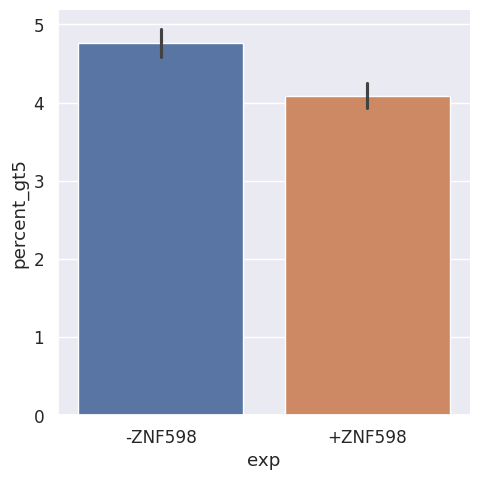

In [21]:
calc = (
    (my_ta.where(my_ta["bad"] == 0)
           ["ch0_mask__major_axis_length_px"] > 5)* 100
)
my_ta["percent_gt5"] = calc
my_ta.plot.catplot(
    x="exp",
    y="percent_gt5",
    kind="bar",
    hue="exp",
)

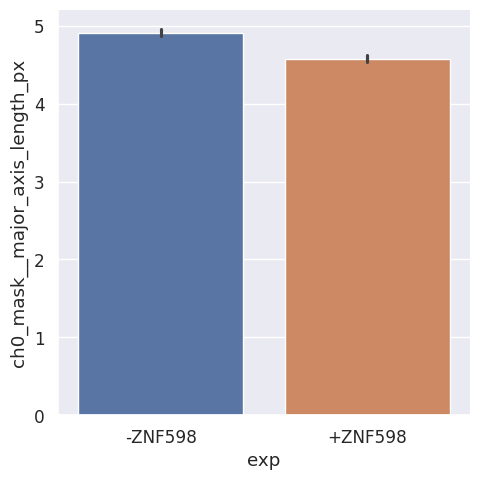

In [22]:
# Make plots using seaborn (relplot, distplot, and catplot supported)
my_ta.where(my_ta.ds["bad"] == 0).plot.catplot(
    x="exp", y="ch0_mask__major_axis_length_px",
    kind="bar",
    hue="exp",
    # col_wrap=4,
    #hue="ch",
    # estimator=None,          # prevents seaborn from averaging
)

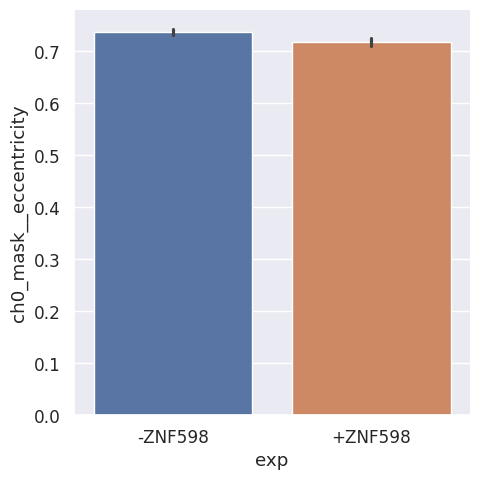

In [23]:
my_ta.where(my_ta.ds["bad"] == 0).mean(dim='t').plot.catplot(
    x="exp", y="ch0_mask__eccentricity",
    kind="bar",
    hue="exp",
)

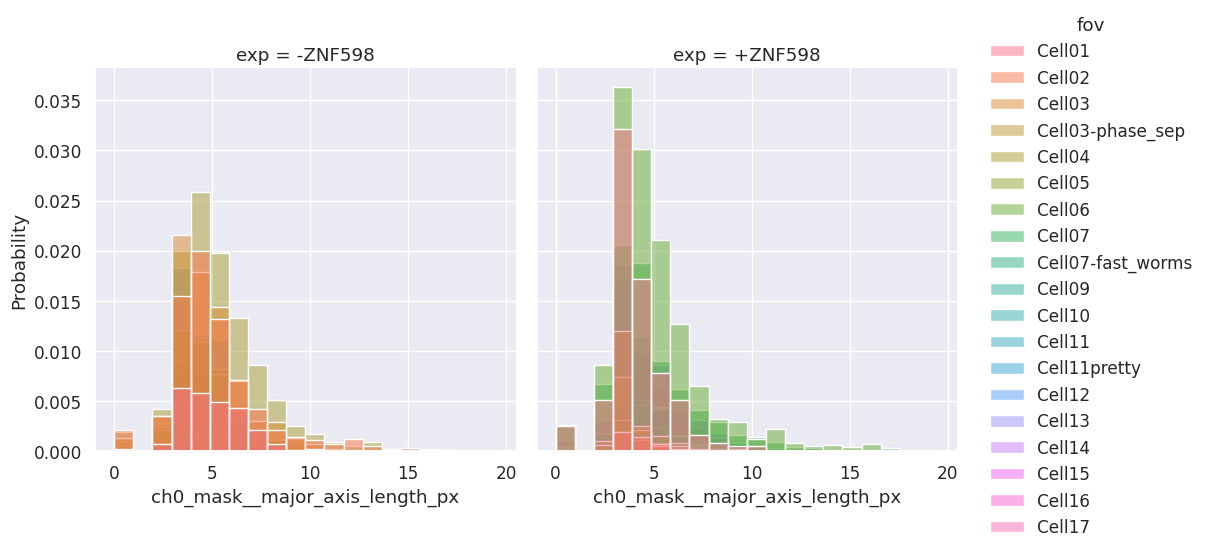

In [24]:
# Make plots using seaborn (relplot, distplot, and catplot supported)
my_ta.where(my_ta.ds["bad"] == 0).plot.displot(
    x="ch0_mask__major_axis_length_px",
    hue="fov",
    col='exp',
    bins=20,
    facet_kws={"sharey": True},
    stat="probability", 
)

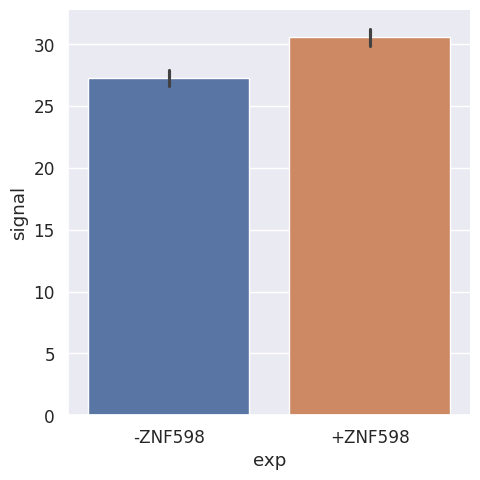

In [26]:
# Make plots using seaborn (relplot, distplot, and catplot supported)
my_ta.where(my_ta.ds["bad"] == 0).plot.catplot(
    x="exp", y="signal",
    kind="bar",
    hue="exp",
    # col_wrap=4,
    #hue="ch",
    # estimator=None,          # prevents seaborn from averaging
)

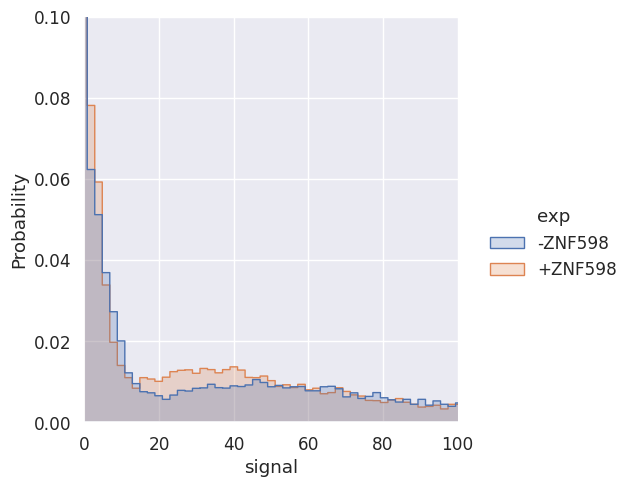

In [ ]:
g=my_ta.where(my_ta.ds["bad"] == 0).plot.displot( x="signal", hue="exp", bins=300, element="step", common_norm=False, stat="probability", aspect=1)
g.set(xlim=(0,100))
g.set(ylim=(0,0.1))